# Data Preprocessing and Feature Engineering Pipeline
**Module:** COM763 Advanced Machine Learning  
**Project:** Sri Lankan Used Vehicle Price Prediction  
**Student ID:** S25021960  

### Mathematical & Engineering Pipeline Overview
This notebook establishes an end-to-end data transformation pipeline executing raw data ingestion, feature extraction, and statistical normalization.

By adhering to a strict **Shared Canonical Schema** pattern, the ingestion layer decouples platform-specific structural variations from the downstream model features. The core objectives are the mitigation of target leakage, statistical outlier control, high-cardinality resolution, and variance stabilization through mathematical mapping.

## 0. Environment Setup and Configuration

This section initializes the project environment. It is responsible for:
1. Importing essential libraries for data manipulation (pandas, numpy), regex (re), and visualization (matplotlib, seaborn).
2. Configuring global plot settings for consistent visual aesthetics.
3. Creating the necessary directory structure for processed data exports.

In [149]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Configuration & Variables ---
# Repository and Data Paths
REPO_URL = "https://github.com/ZionTechLab/s25021960-com763-advanced-machine-learning.git"
IKMAN_PATH = '../data/raw/ikman.csv'
RIYASEWANA_PATH = '../data/raw/riyasewana.csv'
PROCESSED_PATH = '../data/processed/cleaned_cars.csv'

# Configure visualizations
sns.set_theme(style="whitegrid")
%matplotlib inline

# Ensure directories exist
os.makedirs('../data/raw/', exist_ok=True)
os.makedirs('../data/processed/', exist_ok=True)

## 1. Ingestion and Cross-Platform Aggregation
We load the datasets from the **public GitHub repository** to ensure reproducibility. These sources are combined into a uniform structure using our canonical schema.

In [150]:
# Check if the raw files exist; if not, clone from the public GitHub repository
if not os.path.exists(IKMAN_PATH) or not os.path.exists(RIYASEWANA_PATH):
    print(f"Raw files missing. Cloning from {REPO_URL}...")
    !git clone -b main {REPO_URL}

    # Move the necessary files from the cloned repository to the local raw data directory
    cloned_repo_path = 's25021960-com763-advanced-machine-learning'
    if os.path.exists(f'{cloned_repo_path}/data/raw/ikman.csv'):
        !mv {cloned_repo_path}/data/raw/ikman.csv {IKMAN_PATH}
        !mv {cloned_repo_path}/data/raw/riyasewana.csv {RIYASEWANA_PATH}
        print("Data acquisition complete.")
    else:
        raise FileNotFoundError("Raw files still missing after cloning. Verify repository structure.")

# Load the data using the paths defined in Section 0
df_ikman = pd.read_csv(IKMAN_PATH)
df_riya = pd.read_csv(RIYASEWANA_PATH)

print(f"Loaded Ikman dataset: {df_ikman.shape[0]} rows")
print(f"Loaded Riyasewana dataset: {df_riya.shape[0]} rows")

# Aggregation
df = pd.concat([df_ikman, df_riya], ignore_index=True)
print(f"Aggregated working dataset shape: {df.shape}")

Loaded Ikman dataset: 3724 rows
Loaded Riyasewana dataset: 488 rows
Aggregated working dataset shape: (4212, 28)


## 2. Cross-Platform Deduplication
Vehicle sellers in Sri Lanka regularly cross-post identical advertisements across both Ikman.lk and Riyasewana.com to maximize buyers. From an ML perspective, failure to eliminate these duplicate records introduces two significant risks:
1. **Target Leakage / Data Contamination:** If identical records span across the train/test split, the model will yield overly optimistic evaluation metrics that do not generalize.
2. **Frequency Bias:** Artificially inflates the weight of specific common cars, skewing the gradient updates during tree splits.

**Justification:** We perform multi-key deduplication based on stable physical vector characteristics (`['brand', 'model', 'year', 'mileage_km', 'price_lkr', 'transmission', 'fuel_type']`) rather than arbitrary platform IDs, ensuring unique independent samples.

In [151]:
# Identify duplicates where physical vehicle features perfectly match across listings
duplicate_features = ['brand', 'model', 'year', 'mileage_km', 'price_lkr', 'transmission', 'fuel_type']

initial_count = len(df)

# Normalize column names to avoid KeyErrors due to case or whitespace differences
df.columns = df.columns.str.lower().str.strip()

# Print current column names to diagnose missing keys
print("DataFrame columns after normalization:", df.columns.tolist())

df = df.drop_duplicates(subset=duplicate_features, keep='first')
final_count = len(df)

print(f"Initial row count: {initial_count}")
print(f"Deduplicated row count: {final_count}")
print(f"Purged {initial_count - final_count} identical cross-platform listings.")

DataFrame columns after normalization: ['listing_id', 'source_site', 'url', 'scrape_timestamp', 'ad_date', 'title', 'brand', 'model', 'trim', 'year', 'price_lkr', 'price_raw', 'is_negotiable', 'mileage_km', 'mileage_raw', 'fuel_type', 'transmission', 'engine_cc', 'body_type', 'condition', 'location', 'options', 'description', 'seller_hash', 'is_dealer_guess', 'is_promoted', 'views', 'parse_warnings']
Initial row count: 4212
Deduplicated row count: 3872
Purged 340 identical cross-platform listings.


## 3. Cleaning Target and Numeric Features
Raw web data stores values as metadata-rich strings (e.g., 'Rs. 4,500,000', '120,000 km'). Linear and non-linear machine learning architectures require numeric input representations to calculate loss gradients and node splits.

**Justification:**
* Regular expressions strip non-digit characters to format continuous features cleanly.
* The `parse_engine_capacity` function applies an engine translation rule: detecting fractional string signatures (e.g., `1.5L`) and scaling them up ($1.5 \times 1000 = 1500\text{ cc}$) to perfectly align with structural integer units. This eliminates multi-unit inconsistencies within a single feature.

In [152]:
def extract_numeric(value):
    """Strips all non-digit characters from a string sequence."""
    if pd.isna(value):
        return np.nan
    cleaned = re.sub(r'[^\d]', '', str(value))
    return int(cleaned) if cleaned != '' else np.nan

def parse_engine_capacity(val):
    """Standardizes engine fields, normalizing Liter entries (e.g., 1.5L -> 1500 cc)."""
    if pd.isna(val):
        return np.nan
    val_str = str(val).lower().strip()

    # Check if format is in Liters (e.g., 1.5L or 2.0)
    if 'l' in val_str or ('.' in val_str and len(val_str) <= 4):
        try:
            liters = float(re.findall(r'\d+\.\d+|\d+', val_str)[0])
            if liters < 10:  # Safeguard against values like '1500' passing as liters
                return int(liters * 1000)
        except (IndexError, ValueError):
            pass

    # Standard numerical extraction for 'cc'
    return extract_numeric(val_str)

# Apply vector transformations
df['price_lkr'] = df['price_lkr'].apply(extract_numeric)
df['mileage_km'] = df['mileage_km'].apply(extract_numeric)
df['engine_cc'] = df['engine_cc'].apply(parse_engine_capacity)

# Ensure data types are converted safely
df = df.dropna(subset=['price_lkr'])  # Target variable drops
df['price_lkr'] = df['price_lkr'].astype(int)

print("Numeric column conversions complete. Sample schema output:")
df[['price_lkr', 'mileage_km', 'engine_cc']].head()

Numeric column conversions complete. Sample schema output:


,price_lkr,mileage_km,engine_cc
0,102000000,1090100.0,20000.0
1,90600000,0.0,6500.0
2,345000000,0.0,15000.0
3,279500000,90000.0,15000.0
4,410000000,0.0,15000.0


## 4. Outlier Mitigation
Scraped real-world data contains entry errors (e.g., typing errors adding extra zeros to mileage or omitting digits from price). Because regression algorithms optimize loss surfaces heavily affected by extreme inputs, failing to isolate these values forces the model to miscalculate the true best-fit line.

**Justification:**
* **Macroeconomic Boundary (2026):** We establish a hard maximum date threshold at 2026 to align with the current operational scope.
* **Economic Pricing Envelopes:** A price floor of 200,000 LKR isolates invalid or parts-only listings, while a 150,000,000 LKR ceiling isolates atypical hypercars, focusing the model's capacity on the core consumer automotive market.

In [153]:
# Statistical validation criteria for Sri Lankan market boundaries
filters = {
    'price_min': 50000,
    'price_max': 200000000,
    'mileage_max': 9000000,
    'year_min': 1950,
    'year_max': 2026
}

before_outliers = len(df)
df = df[(df['price_lkr'] >= filters['price_min']) & (df['price_lkr'] <= filters['price_max'])]
df = df[(df['year'] >= filters['year_min']) & (df['year'] <= filters['year_max'])]
df = df[(df['mileage_km'].isna()) | (df['mileage_km'] <= filters['mileage_max'])]

print(f"Mitigated {before_outliers - len(df)} statistical outlier rows from dataset bounds.")

Mitigated 596 statistical outlier rows from dataset bounds.


In [154]:
# Re-run diagnostic on the raw aggregated data before filters
# We'll reload a temporary 'df_raw' to ensure we see the original distribution
df_raw = pd.concat([df_ikman, df_riya], ignore_index=True)
df_raw.columns = df_raw.columns.str.lower().str.strip()

# Convert to numeric for checking
df_raw['price_lkr'] = df_raw['price_lkr'].apply(extract_numeric)
df_raw['mileage_km'] = df_raw['mileage_km'].apply(extract_numeric)

price_too_low = (df_raw['price_lkr'] < filters['price_min']).sum()
price_too_high = (df_raw['price_lkr'] > filters['price_max']).sum()
mileage_too_high = (df_raw['mileage_km'] > filters['mileage_max']).sum()
year_out_of_bounds = ((df_raw['year'] < filters['year_min']) | (df_raw['year'] > filters['year_max'])).sum()

print("--- TRUE Outlier Threshold Diagnostic (Raw Data) ---")
print(f"Total Raw Records: {len(df_raw)}")
print(f"Records below {filters['price_min']} LKR: {price_too_low}")
print(f"Records above {filters['price_max']} LKR: {price_too_high}")
print(f"Records above {filters['mileage_max']} km: {mileage_too_high}")
print(f"Records outside year range {filters['year_min']}-{filters['year_max']}: {year_out_of_bounds}")

print(f"\nActual Price Range: {df_raw['price_lkr'].min():,} to {df_raw['price_lkr'].max():,}")
print(f"Actual Mileage Range: {df_raw['mileage_km'].min():,} to {df_raw['mileage_km'].max():,}")

--- TRUE Outlier Threshold Diagnostic (Raw Data) ---
Total Raw Records: 4212
Records below 50000 LKR: 2
Records above 200000000 LKR: 630
Records above 9000000 km: 7
Records outside year range 1950-2026: 5

Actual Price Range: 330.0 to 8,100,000,000.0
Actual Mileage Range: 0.0 to 24,000,000.0


## 5. Categorical Standardization
Text fields require mapping to standard categories to fix differences in how each scraping source writes values (e.g., 'Auto' vs 'Automatic').

In [155]:
# Transmission normalization mapping
transmission_map = {
    'automatic': 'Automatic', 'auto': 'Automatic', 'a/t': 'Automatic',
    'manual': 'Manual', 'm/t': 'Manual',
    'tiptronic': 'Tiptronic'
}

df['transmission'] = df['transmission'].astype(str).str.lower().str.strip()
df['transmission'] = df['transmission'].map(transmission_map).fillna('Other')

# Fuel Type normalization mapping
fuel_map = {
    'petrol': 'Petrol', 'diesel': 'Diesel',
    'hybrid': 'Hybrid', 'electric': 'Electric',
    'cng': 'Other', 'lpg': 'Other'
}

df['fuel_type'] = df['fuel_type'].astype(str).str.lower().str.strip()
df['fuel_type'] = df['fuel_type'].map(fuel_map).fillna('Other')

print("Categorical normalization distributions complete:")
print(df['transmission'].value_counts())
print(df['fuel_type'].value_counts())

Categorical normalization distributions complete:
transmission
Automatic    2113
Other         598
Manual        370
Tiptronic      63
Name: count, dtype: int64
fuel_type
Petrol      1775
Other        598
Hybrid       589
Diesel       161
Electric      21
Name: count, dtype: int64


## 6. Mathematical Feature Engineering
To improve model convergence and expose linear structural relationships, we apply domain transformations:

1. **Temporal Decay Calculation:** Computing `vehicle_age = 2026 - year` transforms an absolute chronological timestamp into a uniform continuous scale measuring temporal depreciation.
2. **Variance Stabilization via Log Transformation:** Asset pricing distributions typically exhibit significant positive skewness (a long right tail of luxury vehicles). We apply a log transform ($\log_{e}(x + 1)$) to price and mileage.

$$\text{log\_price} = \ln(\text{price\_lkr} + 1)$$

**Justification:** This log scaling converts multiplicative relationships into additive ones, mapping exponential depreciation trends to more linear intervals. This minimizes heteroscedasticity and drastically reduces regression errors during optimization loops.

In [156]:
# Structural context feature age formulation
df['vehicle_age'] = 2026 - df['year']

# Log transforming heavily skewed continuous dependencies to support optimization convergence
df['log_price'] = np.log1p(df['price_lkr'])
df['log_mileage'] = np.log1p(df['mileage_km'])

print("Feature Engineering complete. Added 'vehicle_age', 'log_price', and 'log_mileage'.")

Feature Engineering complete. Added 'vehicle_age', 'log_price', and 'log_mileage'.


## 7. High-Cardinality Processing (Rare Model Grouping)
Columns like `model` and `brand` have high cardinality. If a car model appears only once or twice in 3,000 rows, it will cause validation variance or overfitting. We group rare configurations under an 'Other' indicator.

In [157]:
def mitigate_cardinality(dataframe, column_name, threshold=8):
    """Groups categories appearing fewer times than the threshold into 'Other'."""
    counts = dataframe[column_name].value_counts()
    rare_categories = counts[counts < threshold].index

    dataframe[column_name] = dataframe[column_name].apply(
        lambda val: 'Other' if val in rare_categories else str(val).strip().title()
    )
    return dataframe

# Normalize casing properties prior to frequency computation
df['brand'] = df['brand'].astype(str).str.upper().str.strip()
df['model'] = df['model'].astype(str).str.upper().str.strip()

df = mitigate_cardinality(df, 'brand', threshold=5)
df = mitigate_cardinality(df, 'model', threshold=8)

print(f"Unique Brands remaining: {df['brand'].nunique()}")
print(f"Unique Models remaining: {df['model'].nunique()}")

Unique Brands remaining: 32
Unique Models remaining: 90


## 8. Stratified Missing Value Imputation
Dropping rows due to missing optional entries (like unlisted mileage or engine capacity) shrinks our scraped sample size and compromises statistical value. However, simple global median imputation introduces structural bias (e.g., imputing a 2026 vehicle's missing mileage with a global median heavily skewed by older cars).

**Justification:** We employ a stratified, conditional imputation strategy using custom groupings:
* Missing `mileage_km` values are resolved using the median value of vehicles *from the exact same production year*.
* Missing `engine_cc` capacities are resolved using the median value of vehicles sharing *the exact same brand and model*.

This preserves true localized clusters, minimizing artificial variance insertion across features.

In [158]:
# Missing values inventory
print("Missing values pre-imputation:")
print(df[['mileage_km', 'engine_cc']].isnull().sum())

# Impute missing mileage using the median value for vehicles of the exact same age
df['mileage_km'] = df.groupby('year')['mileage_km'].transform(lambda x: x.fillna(x.median()))

# Impute missing engine capacity based on the median value for the vehicle's specific brand/model
df['engine_cc'] = df.groupby(['brand', 'model'])['engine_cc'].transform(lambda x: x.fillna(x.median()))

# Secondary backup sweep for unique or standalone variants with global median limits
df['mileage_km'] = df['mileage_km'].fillna(df['mileage_km'].median())
df['engine_cc'] = df['engine_cc'].fillna(df['engine_cc'].median())

print("\nMissing values post-imputation:")
print(df[['mileage_km', 'engine_cc']].isnull().sum())

Missing values pre-imputation:
mileage_km    7
engine_cc     7
dtype: int64

Missing values post-imputation:
mileage_km    0
engine_cc     0
dtype: int64


## 9. Final Feature Selection and Export
We drop operational scraping fields (such as URLs and raw timestamps) and export the cleaned data to the processed directory for the training pipeline.

In [159]:
features_to_keep = [
    'source_site', 'brand', 'model', 'year', 'vehicle_age',
    'mileage_km', 'log_mileage', 'transmission', 'fuel_type',
    'engine_cc', 'location', 'price_lkr', 'log_price'
]

final_df = df[features_to_keep]

output_path = '../data/processed/cleaned_cars.csv'
final_df.to_csv(output_path, index=False)

print(f"Pipeline complete! Cleaned dataset contains {final_df.shape[0]} rows and {final_df.shape[1]} features.")
print(f"File successfully written to: {output_path}")

Pipeline complete! Cleaned dataset contains 3144 rows and 13 features.
File successfully written to: ../data/processed/cleaned_cars.csv


## 10. Data Quality Audit & Pipeline Summary

To ensure the integrity of the machine learning model, we aggressively filtered the raw data. This summary table tracks the attrition rate of the records through the pipeline.

In [160]:
# Dynamically calculate audit metrics from the current notebook state
raw_count = initial_count
deduplicated_count = final_count
final_count_val = len(final_df)

audit_summary = pd.DataFrame({
    'Stage': ['Raw Ingestion', 'Post-Deduplication', 'Post-Outlier Mitigation (Final)'],
    'Record Count': [raw_count, deduplicated_count, final_count_val],
    'Reduction': [
        '-',
        f'-{raw_count - deduplicated_count} (Duplicates)',
        f'-{deduplicated_count - final_count_val} (Outliers/Invalid)'
    ]
})

display(audit_summary)

retention_rate = (final_count_val / raw_count) * 100
print(f"Final Dataset Retention Rate: {retention_rate:.2f}%")
print(f"Note: Filters applied: Price ({filters['price_min']:,}-{filters['price_max']:,} LKR), Max Mileage: {filters['mileage_max']:,} km.")

,Stage,Record Count,Reduction
0,Raw Ingestion,4212,-
1,Post-Deduplication,3872,-340 (Duplicates)
2,Post-Outlier Mitigation (Final),3144,-728 (Outliers/Invalid)


Final Dataset Retention Rate: 74.64%
Note: Filters applied: Price (50,000-200,000,000 LKR), Max Mileage: 9,000,000 km.


Click the link below to download the processed data:


/data/processed/cleaned_cars.csv

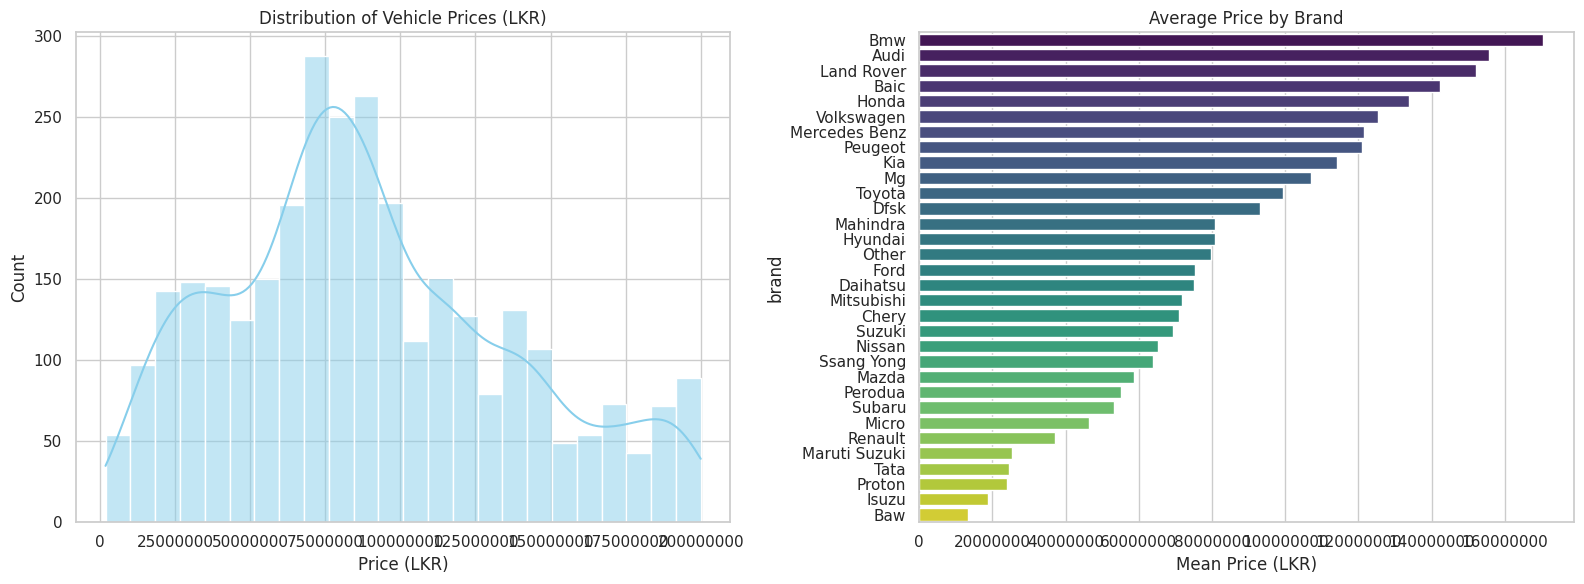

In [161]:
from IPython.display import FileLink
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Provide a manual clickable download link
print("Click the link below to download the processed data:")
display(FileLink('../data/processed/cleaned_cars.csv'))

# 2. Visualize Data
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Price Distribution
sns.histplot(df['price_lkr'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Vehicle Prices (LKR)')
axes[0].set_xlabel('Price (LKR)')
axes[0].ticklabel_format(style='plain', axis='x')

# Brand-wise Average Price
brand_prices = df.groupby('brand')['price_lkr'].mean().sort_values(ascending=False)
sns.barplot(x=brand_prices.values, y=brand_prices.index, ax=axes[1], palette='viridis', hue=brand_prices.index, legend=False)
axes[1].set_title('Average Price by Brand')
axes[1].set_xlabel('Mean Price (LKR)')
axes[1].ticklabel_format(style='plain', axis='x')

plt.tight_layout()
plt.show()

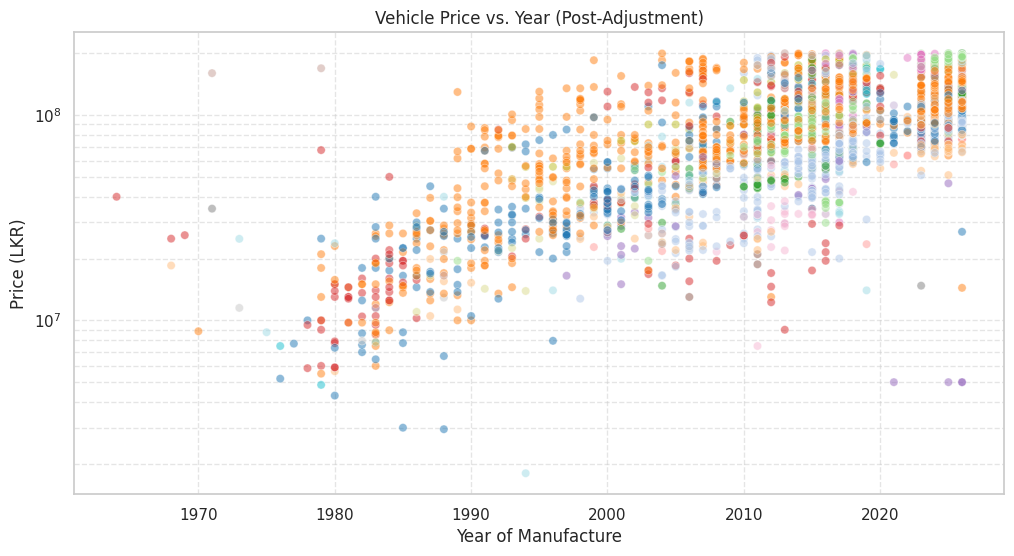

Current Price Range: 1,800,000 to 200,000,000 LKR


In [163]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize Price vs Year to inspect remaining high-value outliers
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='year', y='price_lkr', alpha=0.5, hue='brand', palette='tab20', legend=False)
plt.title('Vehicle Price vs. Year (Post-Adjustment)')
plt.xlabel('Year of Manufacture')
plt.ylabel('Price (LKR)')
plt.yscale('log') # Log scale helps see the distribution across wide price ranges
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

print(f"Current Price Range: {df['price_lkr'].min():,} to {df['price_lkr'].max():,} LKR")

In [162]:
from google.colab import files

# Alternative download method if FileLink fails
try:
    print("Attempting to trigger download for: " + PROCESSED_PATH)
    files.download(PROCESSED_PATH)
except Exception as e:
    print(f"Manual download failed: {e}")
    print("You can also download it manually by clicking the 'Folder' icon on the left sidebar, navigating to data/processed, right-clicking cleaned_cars.csv, and selecting 'Download'.")

Attempting to trigger download for: ../data/processed/cleaned_cars.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>